# Function Definition

In [1]:
import os
import glob
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.dates as mdates

import datetime
from scipy import signal
from scipy.io import wavfile
import pandas as pd

%matplotlib inline

# Sets default style and font parameters for the plots we are making.
mpl.rcParams['font.size']          = 16
mpl.rcParams['font.weight']        = 'bold'
mpl.rcParams['axes.labelweight']   = 'bold'
mpl.rcParams['axes.titleweight']   = 'bold'
mpl.rcParams['figure.labelweight'] = 'bold'
mpl.rcParams['figure.titleweight'] = 'bold'
mpl.rcParams['axes.grid']          = True
mpl.rcParams['grid.linestyle']     = ':'
mpl.rcParams['figure.figsize']     = (12,9)
mpl.rcParams['axes.xmargin']       = 0
mpl.rcParams['axes.ymargin']       = 0.1

### obtain_wav_list()
Allows us to constantly iterate through each wav_list in the respective directory

In [2]:
def obtain_wav_list(directory):
    wav_list = glob.glob(os.path.join(directory,'*.wav'))
    wav_list.sort()
    return wav_list

### load_wav()
Loads the .wav file and subsequently uses the scipy library to convert it into both a signal representation and get the sampling frequency, from there we normalize the signal and compute the time vector. 

In [3]:
def load_wav(fname,normalize=True):
    # Load WAV file.
    fs,x0 = wavfile.read(fname)
    
    if normalize:
        x0   = x0/float(np.max(np.abs(x0)))

    # Compute time vector.
    N  = len(x0)             # Number of samples in signal
    k  = np.arange(len(x0))  # Integer time vector
    Ts = 1/fs                # Sampling Period
    t  = k*Ts
    
    df = pd.DataFrame({'time':t,'x':x0})
    df = df.set_index('time')
    df.attrs['fs'] = fs
    
    return df, fs  

### filter()
load the wav file, apply both a high and low pass freq param that will be used when we take envelope

In [4]:
def filter(wav_df,low_pass_freq=250,high_pass_freq=10,):
    x0  = wav_df
    fs  = wav_df.attrs['fs']

    # Square the signal.
    x1  = x0**2

    # Compute envelope using a rolling max function.
    Tc  = 1.2e-3 # Rolling Max Window [seconds]
    env = x1.rolling(int(Tc*fs),center=True).max()
    env = env.dropna() # Drop NaNs
    
    wp    = low_pass_freq
    ws    = 1.1*wp

    gpass =  3 # The maximum loss in the passband (dB).
    gstop = 40 # The minimum attenuation in the stopband (dB).
     
    N, Wn = signal.buttord(wp, ws, gpass, gstop, fs=fs)
    sos   = signal.butter(N, Wn, 'low', fs=fs, output='sos')

    env_1      = env.copy()
    env_1['x'] = signal.sosfiltfilt(sos,env['x'])

    if high_pass_freq!=0:
        wp    = high_pass_freq
        ws    = 0.8*wp

        gpass =  3 # The maximum loss in the passband (dB).
        gstop = 40 # The minimum attenuation in the stopband (dB).

        N, Wn = signal.buttord(wp, ws, gpass, gstop, fs=fs)
        sos   = signal.butter(N, Wn, 'high', fs=fs, output='sos')

        env_2      = env_1.copy()
        env_2['x'] = signal.sosfiltfilt(sos,env_1['x'])
    else:
        env_2 = env_1
    
    return env_2, fs

### find_chirps()
Finds the respective chirps in the .wav file, Gerard made it so that now we find the maximum correlation and simply sort them out for analysis. For example, instead of providing a sample for where the PN burst is, we give a sample of one chirp showing clean modulation and for the purposes of the April 8 2024 eclipse, find the closes 10 peaks

In [5]:
def find_chirps(wavlist,template,sweep_rate,pfx=None,plot_correlation=False):
    """
    Finds chirps in a list of WAV files using cross-correlation with a template.
    This functions returns the top 10 chirp locations and their correlation coefficients for each WAV file.

    Arguments:
    wavlist : list
        List of paths to WAV files to be analyzed.
    template : str
        Path to the WAV file containing the chirp template.
    sweep_rate : float, optional
        Sweep rate in Hz/ms. Needed for TDOA calculations.
    pfx: str
        String that identifies the transmit and receive station. If None, the pfx will
        be derived from the first name in the wavlist. This is stored as chirps.attrs['pfx'].
    plot_correlation : bool, optional
        If True, plots the correlation results for each WAV file. Default is False. 
    
    Returns:
    chirps : pd.DataFrame
        DataFrame containing:
            'utc' : UTC timestamps
            'data': WAV file data as a pd.DataFrame
            'x'   : indices of chirp starts
            'y'   : cross-correlation coefficients at chirp starts
            'file': path to the source WAV file
    """
    if pfx is None:
        pfx = os.path.basename(wavlist[0])[17:-4]
    
    sample_env,sample_fs = load_wav(template)
    template = sample_env['x']

    # Here we are effectively taking time components
    utcs     = []
    chirps_x = []
    chirps_y = []
    wav_data = []

    for file in wavlist:
        bname   = os.path.basename(file)
        utc_str = bname[:13]
        utc     = datetime.datetime.strptime(utc_str,'%Y%m%d.%H%M')

        wav_env,wav_fs = load_wav(file)
        
        y = signal.correlate(wav_env['x'],template,mode='same')
        x = np.arange(0,len(y),1)

        peaks       = signal.find_peaks(y, distance=300)[0] 
        local_peaks = pd.DataFrame({'x':x[peaks], 'y':y[peaks]})
        local_peaks = local_peaks.sort_values(by='y',ascending=False)

        cx = local_peaks['x'][0:10].sort_index().values # Index locations
        cy = local_peaks['y'][0:10].sort_index().values # Correlation Amplitudes

        utcs.append(utc)
        chirps_x.append(cx)
        chirps_y.append(cy)
        wav_data.append(wav_env)
        
        if plot_correlation:
            fig = plt.figure(figsize=(16,9))
            ax = fig.add_subplot(1,1,1)
            ax.plot(wav_env.index,wav_env['x'])
            for i in range(0,10):
                x0 = cx[i]/wav_fs
                y0 = cy/float(np.max(np.abs(cy)))
                ax.plot([x0,x0],[-y0,y0],color='tab:orange')
            ax.set_xlim(cx[0]/sample_fs-2.5,cx[-1]/sample_fs+2.5)
            ax.set_xlabel('Time [s]')
            ax.set_ylabel('Corr. Coef.')
            ax.set_title(bname)
            plt.show()
            plt.close(fig)
            # clear_output(wait=True)
        else:
            print(file, end = "\r")

    chirps = pd.DataFrame({'utc':utcs,'data':wav_data,'x':chirps_x, 'y':chirps_y,'file':file})
    chirps.attrs['pfx'] = pfx
    chirps.attrs['sweep_rate'] = sweep_rate
    return chirps 

### find_max()

In [6]:
def find_max(freq,X_psd,minfreq,maxfreq):
    peaks = signal.find_peaks(X_psd)[0]
    # print(peaks)
    local_peaks = pd.DataFrame({'f':freq[peaks],'X_psd':X_psd[peaks]})#,'x':f[peaks], 'y':X_psd[peaks]})
    local_peaks = local_peaks.sort_values(by='X_psd',ascending=False)
    
    local_peaks_x = local_peaks.f[local_peaks.f>minfreq][local_peaks.f<maxfreq].values#[local_peaks.X_psd > (0.5 * 10**-5)].values
    local_peaks_y = local_peaks.X_psd[local_peaks.f>minfreq][local_peaks.f<maxfreq].values#[local_peaks.X_psd > (0.5 * 10**-5)].values
    
    if len(local_peaks_x)>0:
        maximum_x = local_peaks_x[0]
        maximum_y = local_peaks_y[0]
    else: 
        maximum_x=np.nan
        maximum_y=np.nan
        
    return maximum_x, maximum_y, local_peaks_x, local_peaks_y

### chirp_fft()

In [7]:
def chirp_fft(df,tlim=None):
    """
    Calculates the FFT of a chirp signal.

    Arguments:
    df : pd.DataFrame
        DataFrame containing the chirp signal with time index and 'x' column.
    tlim : tuple, optional
        Time limits (start, end) to select a portion of the signal for FFT calculation. If None, uses the entire signal.

    Returns:
    X_psd : np.ndarray
        Power Spectral Density of the chirp signal.
    f : np.ndarray
        Frequency vector corresponding to the PSD.
    """
    env    = df['x']
    tvec = df.index
    Ts   = tvec[1] - tvec[0]
    Fs   =1/Ts

    if tlim is None:
        tlim = (0,np.max(tvec))
    elif tlim is not None:
        tf  = np.logical_and(tvec >= tlim[0], tvec <  tlim[1])
        xt  = env[tf].copy()
        
    han_win = np.hanning(len(xt))
    x_han   = han_win*xt
    nfft    = len(x_han)
    if nfft < 2**16: 
        nfft = 2**16

    X_psd   = np.abs(np.fft.fftshift(np.fft.fft(x_han,n=nfft)*Ts*2))**2
    f       = np.fft.fftshift(np.fft.fftfreq(nfft,Ts))
    
    return X_psd, f

def plot_chirp_fft(title, tlim, minfreq, maxfreq, wav_df, sweep_rate, env, tvec, X_psd, f):
    """
    Plots the fft of a chirp signal along with its envelope and raw waveform.

    Arguments:
    title : str
        Title for the plot.
    tlim : tuple
        Time limits (start, end) for the chirp signal.
    minfreq : float
        Minimum frequency for FFT plot.
    maxfreq : float
        Maximum frequency for FFT plot.
    wav_df : pd.DataFrame or None
        DataFrame containing the raw WAV signal. If None, raw signal is not plotted.
    sweep_rate : float
        Sweep rate in Hz/ms for TDOA calculations.
    env : pd.Series
        Envelope of the chirp signal.
    tvec : np.ndarray
        Time vector corresponding to the envelope.
    X_psd : np.ndarray
        Power Spectral Density of the chirp signal.
    f : np.ndarray
        Frequency vector corresponding to the PSD.
    """
    if maxfreq==0:
        maxfreq=10000
    flim = (0,maxfreq)

    nrows = 3
    nax   = 0
    fig = plt.figure(figsize=(15,15))

    nax +=1
    ax  = fig.add_subplot(nrows,1,nax)
    if wav_df is not None:
        xx = wav_df.index
        yy = wav_df['x']
        ax.plot(xx,yy)
        ax.set_xlabel('Time [s]')
        ax.set_ylabel('Amplitude')
        ax.axvspan(*tlim,color='red',label='Selected Chirp')
        ax.legend(loc='upper right')

    nax += 1
    ax  = fig.add_subplot(nrows,1,nax)

    dc_offset = 0
    if wav_df is not None:
        tf  = np.logical_and(wav_df.index >= tlim[0], wav_df.index <  tlim[1])
        wav_xx = wav_df.index[tf]
        wav_yy = wav_df['x'][tf]
        ax.plot(wav_xx,wav_yy,label='Raw WAV')
        dc_offset = np.mean(np.abs(wav_yy))

    env_xx = tvec
    env_yy = env + dc_offset
    ax.plot(env_xx,env_yy,lw=3,color='red',label='Filtered Envelope')
    ax.set_xlim(tlim)
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right')
    ax.set_ylim(0,None)

    nax += 1
    ax = fig.add_subplot(nrows,1,nax)
    ax.plot(f,X_psd)

    maximum_x, maximum_y, local_peaks_x, local_peaks_y = find_max(f,X_psd,minfreq,maxfreq)
    
    ax.plot([maximum_x,maximum_x],[0,maximum_y],linewidth=2)
    ax.plot([0,maximum_x],[maximum_y,maximum_y],linewidth=2, color='red')
    ax.plot([minfreq,minfreq],[0,maximum_y],linewidth=3, color='black')

    lbl = []
    lbl.append(f'$f_b = {maximum_x:0.2f}$ Hz')
    lbl.append(f'TDOA = {maximum_x/sweep_rate:0.2f} ms')
    ax.scatter(maximum_x,maximum_y,linewidths=5,label='\n'.join(lbl),color='green')
    ax.scatter(local_peaks_x,local_peaks_y, color='black')
    ax.set_xlim(flim)
    ax.set_ylim(0,10*10**-5)
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('$|X(f)|^2$')

    # Make x-labels with both beat frequency and TDOA values.
    xticks = ax.get_xticks()
    ax.set_xticks(xticks)
    xtls = []
    for xtk in xticks:
        tdoa = xtk/sweep_rate
        xtl = f'{xtk:0.1f}\n{tdoa:0.1f}'
        xtls.append(xtl)
    xtls[-1] = 'f [Hz]\nTDOA [ms]'
    ax.set_xticklabels(xtls)
    ax.set_xlabel('')
        
    ax.legend()

    _title = []
    _title.append(title)
    _title.append(f'Chirp Sweep Rate: {sweep_rate} Hz/ms')
    plt.suptitle('\n'.join(_title))

    plt.tight_layout()
    # clear_output(wait=True)
    plt.show()
    plt.close(fig)

### find_tdoas()
We finally find TDOAs by finding the maximum frequency in the freq domain and simply dividing it by 10Hz (the sweep rate)

In [8]:
def find_TDOAs(wav_data,search_limits,filter_limts,
               set_name='TDOAs',plot_fft=False,only_one=True):
    """
    Finds TDOAs in a set of WAV files given chirp start locations.

    TDOA [ms] = (Beat Frequency [Hz]) / (Sweep Rate [Hz/ms])

    Arguments:
    wav_data : pd.DataFrame
        DataFrame containing WAV file data and chirp start locations.
    search_limits : tuple, (start_offset, end_offset, min_freq, max_freq)
        This is used to range gate the chirp signal in time to look for an echo from a particular ionospheric region.
        start_offset : float
            Start time offset (in seconds) from chirp start to begin FFT analysis.
        end_offset : float
            End time offset (in seconds) from chirp start to end FFT analysis.
        min_freq : float
            Minimum frequency for FFT peak search.
        max_freq : float
            Maximum frequency for FFT peak search.
    filter_limts : tuple
        Frequency limits for bandpass filtering (low_pass_freq, high_pass_freq).
    set_name : str, optional
        Name of the column to store TDOA results. Default is 'TDOAs'.
    plot_fft : bool, optional
        If True, plots the FFT for each chirp analyzed. Default is False.
    only_one : bool, optional
        If True, processes only the first chirp in first WAV file. Used for debugging.

    Returns:
    wav_data : pd.DataFrame
        Updated DataFrame with TDOA results added.

    """
    sweep_rate = wav_data.attrs['sweep_rate'] # Sweep rate in Hz/ms

    all_beats  = []
    mean_beats = []
    for file_num, row in wav_data.iterrows():
        maxes = []
        wav_df = row['data']
        fpath  = row['file']
        bname  = os.path.basename(fpath)
        wav_env, wav_fs = filter(wav_df,filter_limts[1],filter_limts[0])  

        for peak in wav_data['x'][file_num]: 
            peak = peak/wav_fs
            tlim = (peak+search_limits[0],peak+search_limits[1])
            minfreq=search_limits[2]
            maxfreq=search_limits[3]
            
            X_psd, freq = chirp_fft(wav_env,tlim=tlim)
            
            maximum_x, maximum_y, local_peaks_x, local_peaks_y = find_max(freq,X_psd,minfreq,maxfreq)
            
            if plot_fft:
                plot_chirp_fft(title=bname, tlim=tlim,
                           minfreq=minfreq, maxfreq=maxfreq, wav_df=wav_df, sweep_rate=sweep_rate, 
                           env=wav_env['x'], tvec=wav_env.index, X_psd=X_psd, f=freq)

            maxes.append(maximum_x)
            print(fpath, end = "\r")
            if only_one:
                break
        
        beat_arr = np.array(maxes).flatten()/sweep_rate  # TDOA in ms
        if only_one:
            break
        else:
            all_beats.append(beat_arr)
            mean_beats.append(np.nanmean(beat_arr))
        
    if not only_one:
        wav_data[set_name]           = all_beats
        wav_data[f'{set_name}_mean'] = mean_beats
    return wav_data

# Begin Processing

## Load WAVs & Find Chirps

In [9]:
base_dir   = 'data'
data_set   = 'TX_WA5FRF_EL09nn-RX_N6RFM_EM12jw-0407KM-40m'
sweep_rate = 10  # Hz/ms

# Path to chirp template - used for finding chirp locations via cross-correlation
template   = os.path.join('templates','N6RFM_10Hz_per_ms_template.wav')

data_dir   = os.path.join(base_dir,data_set)
wavlist    = obtain_wav_list(data_dir)

In [10]:
# Correlate each WAV with a known template chirp to identify chirp locations in each WAV file.
chirps = find_chirps(wavlist,template,sweep_rate=sweep_rate,plot_correlation=False)

## Find TDOAs

In [11]:
debug_TDOAs = False

tdoa_dct = {}

### 1F2-2F2
tdoa_dct['1F2-2F2']  = dct = {}
dct['filter_limts']  = [10,50]          # Bandpass filter limits [Hz]
dct['search_limits'] = [-0.1,0.1,11,20] # (start_offset, end_offset, min_freq, max_freq)
dct['model_coeffs']  = (140.2,48.3)     # (slope,intercept) for layer height model
dct['linestyle']     = '--'
dct['linewidth']     = 3
dct['color']         = 'tab:green'

### 1F2-1E
tdoa_dct['1F2-1E']   = dct = {}
dct['filter_limts']  = [2.5,30]        # Bandpass filter limits [Hz]
dct['search_limits'] = [-0.1,0.1,5,12] # (start_offset, end_offset, min_freq, max_freq)
dct['model_coeffs']  = (181.8,135.5)   # (slope,intercept) for layer height model
dct['linestyle']     = '-.'
dct['linewidth']     = 1.5
dct['color']         = 'tab:blue'

### 2F2-1E
tdoa_dct['2F2-1E'] = dct = {}
dct['filter_limts']  = [20,30]          # Bandpass filter limits [Hz]
dct['search_limits'] = [-0.1,0.1,22,30] # (start_offset, end_offset, min_freq, max_freq)
dct['model_coeffs']  = (79.4,85.6)      # (slope,intercept) for layer height model
dct['linestyle']     = ':'
dct['linewidth']     = 2.5
dct['color']         = 'tab:orange'

for set_name, params in tdoa_dct.items():
    filter_limts  = params['filter_limts']
    search_limits = params['search_limits']
    chirps        = find_TDOAs(chirps,search_limits,filter_limts,set_name=set_name
                               ,plot_fft=debug_TDOAs,only_one=debug_TDOAs)

/var/folders/bz/ym0kqkts57sd2tqtpp__3y29gzth2_/T/ipykernel_34051/4239382467.py:71: RuntimeWarning: Mean of empty slice
  mean_beats.append(np.nanmean(beat_arr))


# Figure 13

In [ ]:
def plot_TDOAs(chirps, tdoa_dct, ylim=(0,3)):
    times = chirps['utc']
    fig   = plt.figure(figsize=(16, 9))
    ax    = fig.add_subplot(1, 1, 1)

    for set_name, params in tdoa_dct.items():
        TDOAs = chirps[f'{set_name}_mean']
        line, = ax.plot(times, TDOAs, 
                label=set_name, 
                marker = params.get('marker','o'),
                linestyle=params.get('linestyle'),
                linewidth=params.get('linewidth'),
                color=params.get('color'))

    ax.set_ylim(ylim)
    
    myFmt = mdates.DateFormatter('%H:%M')
    ax.xaxis.set_major_formatter(myFmt)
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=15))

    ax.set_ylabel('TDOA [ms]')
    ax.set_xlabel('Time UTC')

    # TODO: Fix legend.
    ax.legend()

    title = chirps.attrs.get('pfx','')
    ax.set_title(title)
    fig.autofmt_xdate()
    
    plt.tight_layout()
    plt.show()
    plt.close(fig)

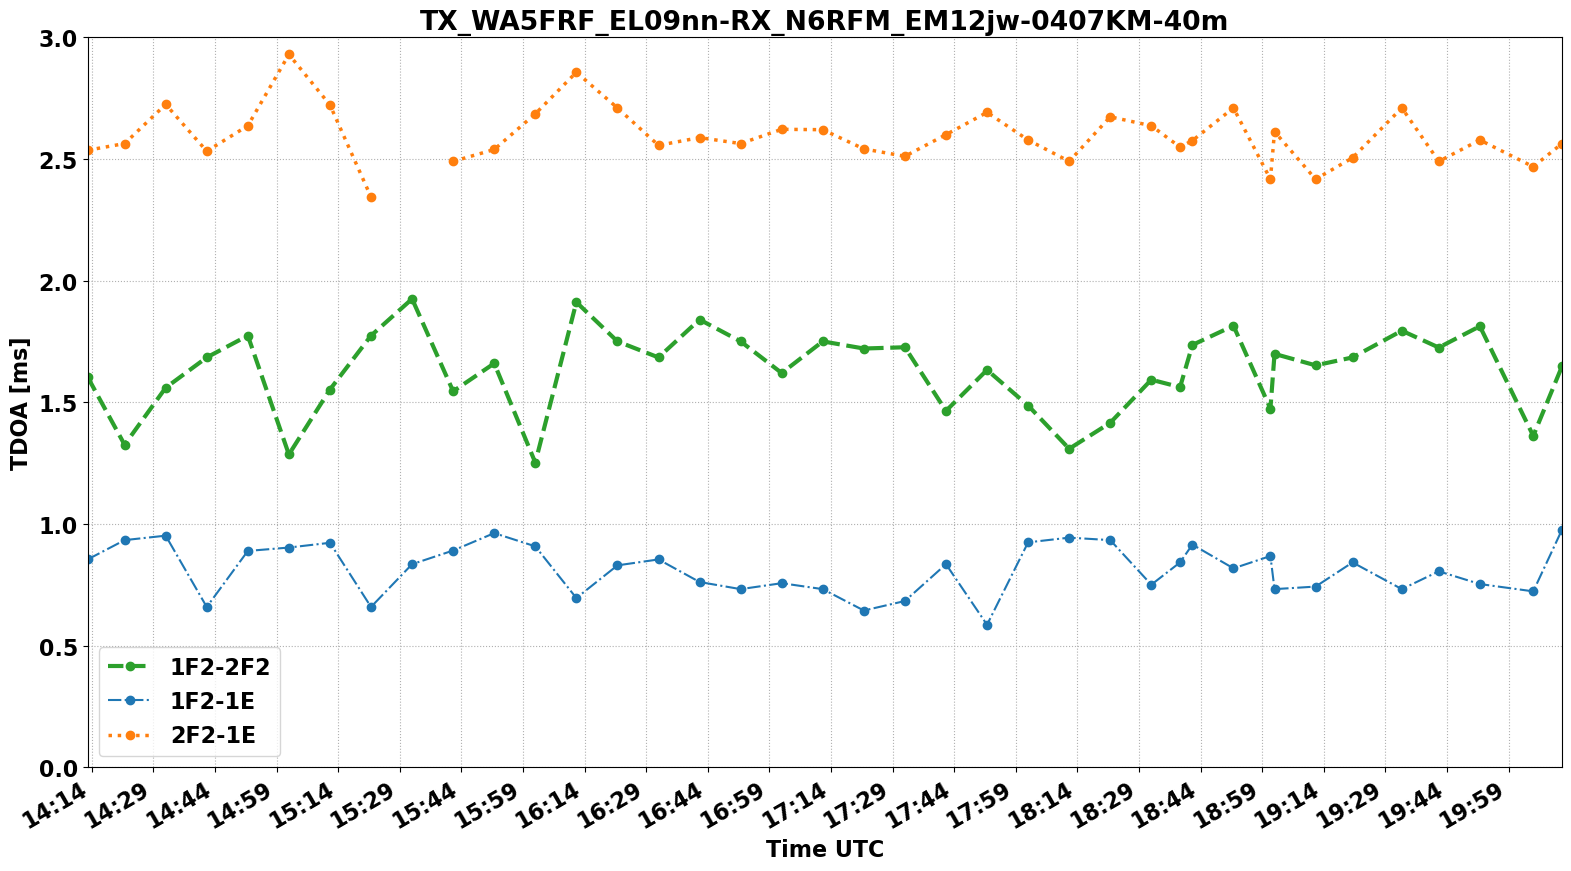

In [13]:
plot_TDOAs(chirps,tdoa_dct)

# Figure 14

Alrighty, time to overlay Austin Ionosonde at least HMF2

In [14]:
IonosondeLayer_Height = [263, 258.2, 253.2, 246.7, 249.7, 254.8, 249.8, 253, 252, 265.7, 275.6, 279.7, 275.5, 277.7, 279.2, 270.8, 263.5, 265.8, 283.6, 286, 298.1, 295.5, 297.2, 292.7, 295.6, 299.7, 296.4, 293, 288.3, 284.5, 280.7, 285, 298.6, 287.8, 286.5, 279.3, 283.8, 296.8, 289.1, 300.3, 291.9, 288.9, 300.4, 295.8, 289.4, 292, 300.7, 290.9, 307.4, 304.7, 292.8, 302.3, 313.6, 308.7, 300, 291.7, 302.4, 303.7, 301, 306.2, 298.3, 284.9, 291.4, 293.8, 292.5, 302.4, 286.6, 285.9, 276.5, 288, 286.5, 278.9, 275.9, 270.6, 280.7, 276.1, 273.1, 275.7, 279.2, 299.5, 290.9, 285.8, 278.9, 281, 288.8, 279.9, 281, 277.4, 277, 271.5, 276.9]
Ionosonde_times = [
    "14:00:05", "14:05:05", "14:10:05", "14:15:05", "14:20:05", "14:25:05", "14:30:05", "14:35:05", "14:40:05", "14:45:05",
    "14:50:05", "14:55:05", "15:00:05", "15:05:05", "15:10:05", "15:15:05", "15:20:05", "15:25:05", "15:30:05", "15:35:05",
    "15:40:05", "15:45:05", "15:50:05", "15:55:05", "16:00:05", "16:05:05", "16:10:05", "16:15:05", "16:20:05", "16:25:05",
    "16:30:05", "16:35:05", "16:40:05", "16:45:05", "16:50:05", "16:55:05", "17:00:05", "17:05:05", "17:10:05", "17:15:05",
    "17:20:05", "17:25:05", "17:30:05", "17:35:05", "17:40:05", "17:45:05", "17:50:05", "17:55:05", "18:00:05", "18:05:05",
    "18:10:05", "18:15:05", "18:20:05", "18:25:05", "18:30:05", "18:35:05", "18:40:05", "18:45:05", "18:50:05", "18:55:05",
    "19:00:05", "19:05:05", "19:10:05", "19:15:05", "19:20:05", "19:25:05", "19:30:05", "19:35:05", "19:40:05", "19:45:05",
    "19:50:05", "19:55:05", "20:00:05", "20:05:05", "20:10:05", "20:15:05", "20:20:05", "20:25:05", "20:30:05", "20:35:05",
    "20:40:05", "20:45:05", "20:50:05", "20:55:05", "21:00:05", "21:05:05", "21:10:05", "21:15:05", "21:20:05", "21:25:05",
    "21:30:05"
]
date_str = "2024-04-08"
Ionosonde_datetimes = [datetime.datetime.strptime(date_str + " " + time_str, "%Y-%m-%d %H:%M:%S") for time_str in Ionosonde_times]
print(Ionosonde_datetimes)

[datetime.datetime(2024, 4, 8, 14, 0, 5), datetime.datetime(2024, 4, 8, 14, 5, 5), datetime.datetime(2024, 4, 8, 14, 10, 5), datetime.datetime(2024, 4, 8, 14, 15, 5), datetime.datetime(2024, 4, 8, 14, 20, 5), datetime.datetime(2024, 4, 8, 14, 25, 5), datetime.datetime(2024, 4, 8, 14, 30, 5), datetime.datetime(2024, 4, 8, 14, 35, 5), datetime.datetime(2024, 4, 8, 14, 40, 5), datetime.datetime(2024, 4, 8, 14, 45, 5), datetime.datetime(2024, 4, 8, 14, 50, 5), datetime.datetime(2024, 4, 8, 14, 55, 5), datetime.datetime(2024, 4, 8, 15, 0, 5), datetime.datetime(2024, 4, 8, 15, 5, 5), datetime.datetime(2024, 4, 8, 15, 10, 5), datetime.datetime(2024, 4, 8, 15, 15, 5), datetime.datetime(2024, 4, 8, 15, 20, 5), datetime.datetime(2024, 4, 8, 15, 25, 5), datetime.datetime(2024, 4, 8, 15, 30, 5), datetime.datetime(2024, 4, 8, 15, 35, 5), datetime.datetime(2024, 4, 8, 15, 40, 5), datetime.datetime(2024, 4, 8, 15, 45, 5), datetime.datetime(2024, 4, 8, 15, 50, 5), datetime.datetime(2024, 4, 8, 15, 55,

In [15]:
IonosondeLayer_HeighthmE = [101.2, 101, 110, 97.2, 97.4, 97.1, 89.6, 90.3, 110, 98.7, 110, 91.5, 88.5, 90, 102.3, 97.7, 89.8, 110, 100, 90.8, 93.8, 93.1, 110, 107.2, 110, 119.1, 97.2, 97, 101.5, 100.8, 108.4, 110, 110, 110, 101.1, 110, 103.4, 96.5, 110, 120.5, 110, 110, 101.2, 111, 110, 110, 110, 110, 97.5, 90.3, 97.8, 110, 105.3, 113.8, 119.6, 110, 110, 116.1, 108.6, 110, 110, 114.5, 100.9, 99.4, 93.7, 110, 120.2, 85.8, 93.4, 89.6, 110, 107.3, 110, 110, 101.9, 123.3, 93.6, 110, 99.1, 110, 105.3, 95.5, 118.5, 95.6, 110, 110, 108.6, 101.6, 93.3, 102.5, 110]
Ionosonde_timeshmE = [
    "14:00:05", "14:05:05", "14:10:05", "14:15:05", "14:20:05", "14:25:05", "14:30:05", "14:35:05", "14:40:05", "14:45:05",
    "14:50:05", "14:55:05", "15:00:05", "15:05:05", "15:10:05", "15:15:05", "15:20:05", "15:25:05", "15:30:05", "15:35:05",
    "15:40:05", "15:45:05", "15:50:05", "15:55:05", "16:00:05", "16:05:05", "16:10:05", "16:15:05", "16:20:05", "16:25:05",
    "16:30:05", "16:35:05", "16:40:05", "16:45:05", "16:50:05", "16:55:05", "17:00:05", "17:05:05", "17:10:05", "17:15:05",
    "17:20:05", "17:25:05", "17:30:05", "17:35:05", "17:40:05", "17:45:05", "17:50:05", "17:55:05", "18:00:05", "18:05:05",
    "18:10:05", "18:15:05", "18:20:05", "18:25:05", "18:30:05", "18:35:05", "18:40:05", "18:45:05", "18:50:05", "18:55:05",
    "19:00:05", "19:05:05", "19:10:05", "19:15:05", "19:20:05", "19:25:05", "19:30:05", "19:35:05", "19:40:05", "19:45:05",
    "19:50:05", "19:55:05", "20:00:05", "20:05:05", "20:10:05", "20:15:05", "20:20:05", "20:25:05", "20:30:05", "20:35:05",
    "20:40:05", "20:45:05", "20:50:05", "20:55:05", "21:00:05", "21:05:05", "21:10:05", "21:15:05", "21:20:05", "21:25:05",
    "21:30:05"
]

date_str = "2024-04-08"
Ionosonde_datetimeshmE = [datetime.datetime.strptime(date_str + " " + time_str, "%Y-%m-%d %H:%M:%S") for time_str in Ionosonde_timeshmE]

In [18]:
def plothmf2V2(chirps, tdoa_dct,ylim=(75,450)):
    times = chirps['utc']

    times = np.array(times)    
    fig = plt.figure(figsize=(16, 9))
    ax = fig.add_subplot(1, 1, 1)
    
    for set_name, params in tdoa_dct.items():
        TDOAs = chirps[f'{set_name}_mean']
        coefs = params['model_coeffs']
        layer_heights = (coefs[0] * TDOAs) + coefs[1]

        line, = ax.plot(times, layer_heights, 
                label=set_name, 
                marker = params.get('marker','o'),
                linestyle=params.get('linestyle'),
                linewidth=params.get('linewidth'),
                color=params.get('color'))
    
    ax.set_ylim(ylim)
    
    myFmt = mdates.DateFormatter('%H:%M')
    ax.xaxis.set_major_formatter(myFmt)
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
    ax.set_ylabel('Layer Height [km]')
    ax.set_xlabel('Time UTC')
    
    ax.plot(Ionosonde_datetimes,IonosondeLayer_Height, color = 'purple', label = "Austin Ionosonde hmf2", linewidth = 2)
    ax.plot(Ionosonde_datetimeshmE,IonosondeLayer_HeighthmE, color = 'brown', label = "Austin Ionosonde hmE", linewidth = 2)
    ax.legend()
    fig.autofmt_xdate()

    plt.tight_layout()
    plt.show()

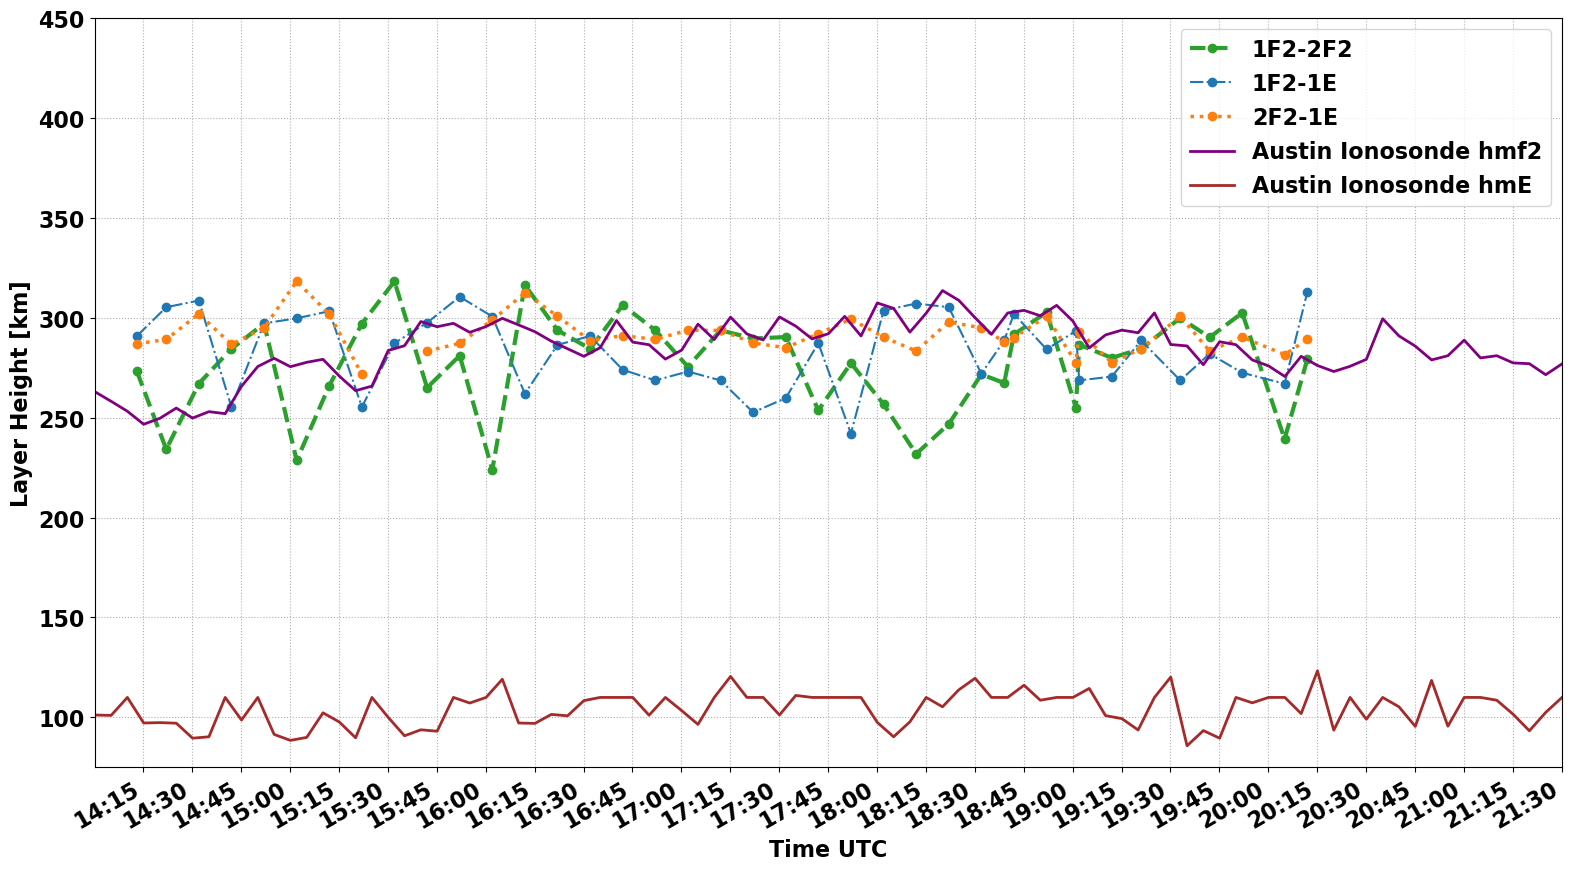

In [19]:
plothmf2V2(chirps,tdoa_dct)